# 201 · Group Sequential Design

Traditional A/B testing requires you to wait until a pre-determined sample size ($N_{fix}$) is reached. **Group Sequential Design (GSD)** allows you to perform "interim looks" and stop early for either success (**Efficacy**) or failure (**Futility**), while strictly controlling the Type I error rate.

In this tutorial, we will:
- Design a Binomial A/B test using the **Lan-DeMets (Spending Function)** approach.
- Visualize the operating characteristics of the design.
- Perform sequential monitoring.

## 1. Setup & Design

We use the `GST_Spending_JennisonTurnbull2000` controller. This controller encapsulates the complex math of alpha-spending boundaries.

In [1]:
import ibis
import matplotlib.pyplot as plt

from earlysign.controllers.GST_Spending_JennisonTurnbull2000 import (
    JennisonTurnbull2000Controller,
)
from earlysign.core.ledger import Ledger
from earlysign.schema.ES3.Binomial import BinomialArmData
from earlysign.schema.ES3.GST.Log import DecisionStatus

ledger = Ledger(ibis.connect("duckdb://:memory:"), "gsd_events").bind(
    exp_id="gsd_tutorial"
)
ledger.ensure()

# 1. Design the protocol
# 5 Looks, O-Brien Fleming boundaries.
controller = JennisonTurnbull2000Controller(ledger)
protocol = controller.design(
    p_control=0.10,
    p_treatment=0.12,
    alpha=0.05,
    power=0.8,
    looks=3,
    spending_function="obrien_fleming",
)

print("Let's take a look at the designed stopping policy.")
print(
    f"Planned Max N: {sum(protocol.method.stopping_policy.timer.max_sample_size.values())}"
)
protocol.model_dump()["method"]["stopping_policy"]

Let's take a look at the designed stopping policy.
Planned Max N: 5932


{'statistic': {'kind': 'two_arm_binomial_z'},
 'strategy': {'kind': 'alpha_beta_spending',
  'statistical_model': {'kind': 'canonical_gaussian'},
  'alpha_spending_fn': {'family': 'obrien_fleming', 'params': None},
  'beta_spending_fn': {'family': 'obrien_fleming', 'params': None},
  'alpha_budget': 0.05,
  'beta_budget': 0.2,
  'alpha_binding': True,
  'beta_binding': False},
 'timer': {'kind': 'sample_size',
  'unit': <Unit.INDIVIDUALS: 'individuals'>,
  'max_sample_size': {'control': 2966, 'treatment': 2966}},
 'schedule': {'kind': 'fixed',
  'analyses': [0.4777454510334777, 0.7049899412834755, 1.0]},
 'trigger_strategy': {'kind': 'due_look', 'tolerance': 0.0}}

## 2. Visualize Operating Characteristics

How will the above protocol perform in the trial?
Before starting the trial, it is important to check the "Operating Characteristics" (OC) such as the Expected Sample Size (ESS) and Power across different true effect sizes.

,Effect Size (%),Power,Expected N,Fixed N (Ref),ESS / Fixed (%),ESS / Max (%),Max N (Total),Prob > Fixed N,Prob Stop (Look 1),Prob Stop (Look 2),Prob Stop (Look 3)
0,-20.000000,0.0%,2849.8,5564.3,51.2%,48.0%,5932.0,0.1%,99.0%,0.9%,0.1%
1,-15.000000,0.1%,2878.1,5564.3,51.7%,48.5%,5932.0,0.4%,97.2%,2.5%,0.4%
2,-10.000000,0.1%,2964.0,5564.3,53.3%,50.0%,5932.0,1.5%,92.3%,6.1%,1.5%
3,-5.000000,1.0%,3142.4,5564.3,56.5%,53.0%,5932.0,5.2%,83.9%,10.8%,5.2%
4,0.000000,4.2%,3407.5,5564.3,61.2%,57.4%,5932.0,11.3%,72.1%,16.5%,11.3%
5,5.000000,13.2%,3797.4,5564.3,68.2%,64.0%,5932.0,21.8%,56.9%,21.3%,21.8%
6,10.000000,31.1%,4157.3,5564.3,74.7%,70.1%,5932.0,31.5%,42.7%,25.8%,31.5%
7,15.000000,54.3%,4315.6,5564.3,77.6%,72.8%,5932.0,34.2%,34.5%,31.3%,34.2%
8,20.000000,75.6%,4149.2,5564.3,74.6%,69.9%,5932.0,27.2%,37.7%,35.1%,27.2%
9,25.000000,90.2%,3850.3,5564.3,69.2%,64.9%,5932.0,17.6%,47.4%,35.0%,17.6%


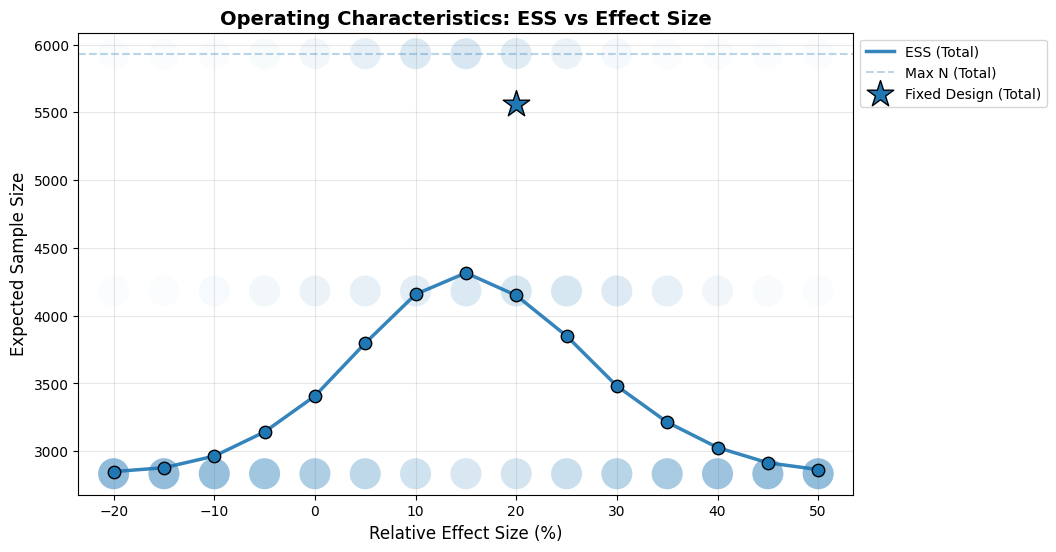

In [2]:
from earlysign.methods.group_sequential.reporting.visualization import (
    visualize_protocol_design,
)

# Visualize the design
res = visualize_protocol_design(protocol, effect_sizes=list(range(-20, 50 + 5, 5)))
display(res["summary"])
display(res["figure"])

It looks fine, so let's actually use this protocol.

In [3]:
# Write protocol to the ledger
controller.set_protocol(protocol)

## 3. Sequential Monitoring

We simulate data arriving in batches. After each `update()`, we check the progress.

In [4]:
import numpy as np

# Initialize random number generator for reproducibility
rng = np.random.default_rng(42)

p_c, p_t = 0.10, 0.14  # True effect is larger than designed delta (0.02)
n_per_batch = 200

for iteration in range(1, 15):
    # 1. New data arrives
    batch = [
        BinomialArmData(
            total=n_per_batch, success=rng.binomial(n_per_batch, p_c), arm="control"
        ),
        BinomialArmData(
            total=n_per_batch, success=rng.binomial(n_per_batch, p_t), arm="treatment"
        ),
    ]

    # 2. Analyze
    controller.update(batch)

    # 3. Decision Check
    report = controller.report_progress()
    status = report["status"]
    n_curr = report["sample_n"]
    z_curr = report["z_stat"]

    # Milestone logic
    is_milestone = report.get("is_milestone", False)
    next_m = report.get("next_milestone_n")

    if is_milestone:
        trigger_msg = f"[LOOK {report['look']} TRIGGERED]"
    elif next_m is not None:
        trigger_msg = f"(Need {next_m} for next look)"
    else:
        trigger_msg = ""

    z_str = f", Z={z_curr:.3f}" if z_curr is not None else ""
    print(f"Batch {iteration:02d}: N={n_curr}{z_str}, Status={status} {trigger_msg}")

    if status != DecisionStatus.CONTINUE:
        print(f"\n>>> STOP DETERMINED AT N={n_curr}!")
        break

Batch 01: N=400, Z=0.605, Status=continue (Need 2833 for next look)
Batch 02: N=800, Z=0.942, Status=continue (Need 2833 for next look)
Batch 03: N=1200, Z=2.732, Status=continue (Need 2833 for next look)
Batch 04: N=1600, Z=3.017, Status=continue (Need 2833 for next look)
Batch 05: N=2000, Z=3.553, Status=continue (Need 2833 for next look)
Batch 06: N=2400, Z=4.272, Status=continue (Need 2833 for next look)
Batch 07: N=2800, Z=4.619, Status=continue (Need 2833 for next look)
Batch 08: N=3200, Z=4.626, Status=stop_efficacy [LOOK 1 TRIGGERED]

>>> STOP DETERMINED AT N=3200!


## 4. Visualize the Trajectory

Controllers provide built-in plotting to visualize the boundaries and the test statistic's path.

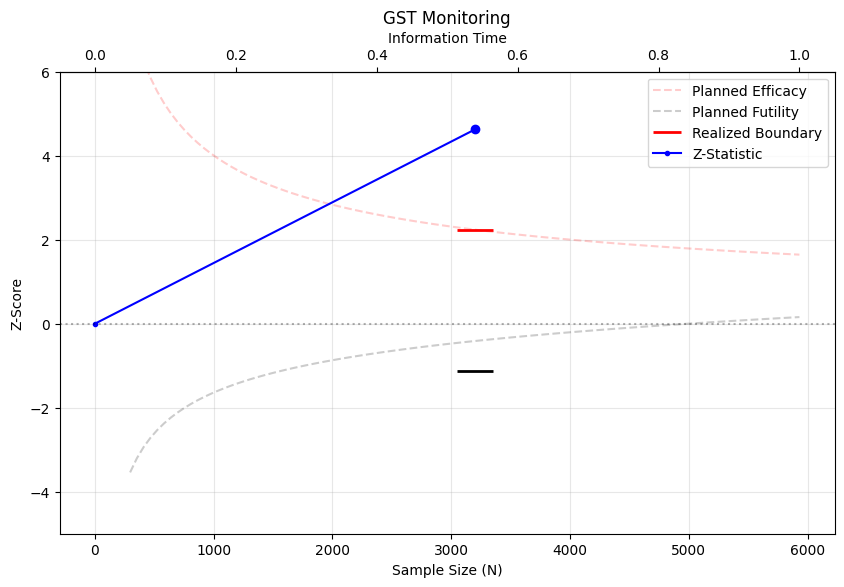

In [5]:
controller.plot_result()
plt.show()

For educational purposes, here's how the graph would have looked like if we computed the Z score on each step of the update:

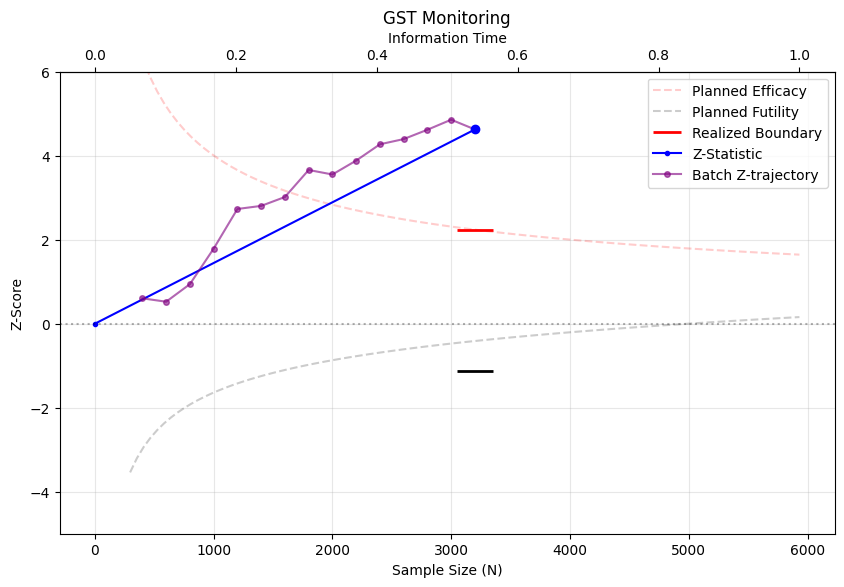

In [6]:
from earlysign.methods.group_sequential.reporting.inspection import (
    PosthocZTrajectoryProjector,
)

# 1. Generate the base plot (realized boundaries + look Z-stats)
fig = controller.plot_result()
ax = fig.axes[0]

# 2. Reconstruct high-resolution Z-scores directly from the ledger using core inspection utilities.
z_trajectory = PosthocZTrajectoryProjector().project(controller.ledger.t).data.execute()

# 3. Overlay the high-resolution trajectory
if not z_trajectory.empty:
    ax.plot(
        z_trajectory["n"],
        z_trajectory["z"],
        color="purple",
        linestyle="-",
        marker="o",
        markersize=4,
        alpha=0.6,
        label="Batch Z-trajectory",
    )
    ax.legend()
plt.show()

## 5. Summary

- **GSD**: Enables early stopping for efficient resource use.
- **Spending Functions**: Map boundaries to alpha expenditure over time, enabling flexible look timing.

In the next tutorial, we will explore **Anytime Valid Inference**, which removes the need to pre-specify the number of looks entirely.